In [2]:
# from sklearn.preprocessing import StandardScaler
import pandas as pd
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import plotly.express as px

%matplotlib inline

sns.set_theme('notebook', palette='muted')
sys.path.append(r"D:\HopeAI\Assignments\MyModules")

from data_analysis_utils import Univariate, Preprocessing

dataset = pd.read_csv(r"D:\HopeAI\Assignments\ML and DS Capstone\2. Data Preprocessing\PreStockFeatures.csv")
dataset


,Stock,Sector,Industry,MarketCap,Cap Category,Annualized_Return,Annualized_Volatility,Sharpe_Ratio,Max_Drawdown,Avg_Volume,Volume_Spike_Pct,Beta_vs_NIFTY,Corr_with_NIFTY
0,360ONE,Financial Services,Asset Management,445803167744,Mid Cap,3.524515,0.589975,5.889254,30.097756,4.899030e+05,11.111111,0.639538,0.260950
1,AARTIIND,Basic Materials,Specialty Chemicals,138456645632,Small Cap,-0.517008,0.585279,-0.968783,63.172265,1.300992e+06,7.317073,1.252114,0.514999
2,ABB,Industrials,Specialty Industrial Machinery,1090798354432,Large Cap,2.615783,0.571198,4.491934,26.442369,3.516467e+05,6.368564,0.862478,0.363485
3,ABCAPITAL,Financial Services,Financial Conglomerates,781306822656,Mid Cap,0.639011,0.573486,1.027072,35.630066,5.000453e+06,9.214092,1.392779,0.584635
4,ABREL,Basic Materials,Paper & Paper Products,178644762624,Small Cap,2.476973,0.697101,3.481524,39.647621,3.216849e+05,10.704607,1.227745,0.423973
...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,WIPRO,Technology,Information Technology Services,2567080247296,Large Cap,-0.058463,0.432499,-0.250782,50.015772,1.370024e+07,5.555556,1.081205,0.601794
263,WOCKPHARMA,Healthcare,Drug Manufacturers - Specialty & Generic,225707163648,Small Cap,4.216138,0.828349,5.029448,63.056593,1.059813e+06,10.027100,0.982579,0.285548
264,YESBANK,Financial Services,Banks - Regional,754220466176,Mid Cap,0.777135,0.707369,1.027943,39.267516,1.655482e+08,10.569106,1.091840,0.371568
265,ZENTEC,Industrials,Aerospace & Defense,125330620416,Small Cap,14.446618,0.809376,17.787296,34.040224,5.798867e+05,10.840108,0.969627,0.288389


In [3]:
quan, qual = Preprocessing.quanQual(dataset)
quan = quan.delete(1) # Remove Year column
descriptive = Univariate.descriptive(dataset, quan)
descriptive.T


,Mean,Mode,Min,Q1-25th%,Median / Q2-50%,Q3-75th%,99th%,Max-100th%,IQR,1.5rule,LesserRange,GreaterRange,Skew,Kurtosis,Var,Std
MarketCap,1298832838425.889893,104417591296,104417591296,273103314944.0,656710762496.0,1275712700416.0,11165484271534.060547,18607148892160,1002609385472.0,1503914078208.0,-1230810763264.0,2779626778624.0,2.25,5.25,29736708682193075114606592.0,7677985166476325620285440.0
Annualized_Volatility,0.61,0.319594,0.319594,0.486359,0.583812,0.697322,1.01,1.040602,0.210963,0.316444,0.169915,1.013766,0.46,-0.99,0.26,0.0
Sharpe_Ratio,3.48,-0.968783,-0.968783,0.769612,2.311186,4.459732,19.83,26.683484,3.690119,5.535179,-4.765566,9.99491,1.44,2.15,71.63,19.0
Max_Drawdown,36.99,14.894649,14.894649,27.126151,34.49703,44.431558,77.68,86.455268,17.305407,25.958111,1.16804,70.389669,0.72,-0.52,812.18,203.0
Avg_Volume,7943344.12,9423.917344,9423.917344,613225.748645,1828773.588076,6268062.898374,78741875.94,256268654.380759,5654837.149729,8482255.724593,-7869029.975949,14750318.622967,3.0,10.14,4803197105824274.0,1240180153086962.0
Volume_Spike_Pct,8.47,7.99458,3.658537,6.775068,8.265583,10.0271,13.69,14.769648,3.252033,4.878049,1.897019,14.905149,0.3,-0.97,26.6,7.0
Beta_vs_NIFTY,0.99,0.351879,0.351879,0.78926,0.993927,1.21319,1.66,1.796427,0.423931,0.635896,0.153364,1.849087,0.41,-1.06,0.59,1.0
Corr_with_NIFTY,0.4,0.085209,0.085209,0.304429,0.401526,0.489184,0.67,0.710286,0.184755,0.277132,0.027297,0.766316,0.29,-0.93,0.17,0.0


## 1. Which sectors have the top-performing stocks according to annualized return

                    Sector  Annualized_Return
0              Industrials          25.713159
1               Technology          17.109775
2          Basic Materials          16.938243
3              Real Estate          14.569770
4        Consumer Cyclical          13.525041
5               Healthcare          13.128012
6       Financial Services          11.482553
7                Utilities           7.058270
8       Consumer Defensive           5.637929
9                   Energy           4.095730
10  Communication Services           1.495283


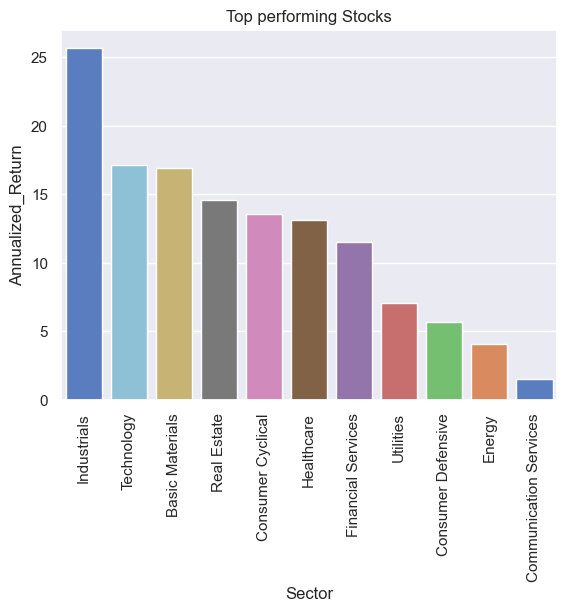

In [4]:
ann_ret = dataset.groupby('Sector')['Annualized_Return'].max().sort_values(ascending=False).reset_index()
print(ann_ret)
sns.barplot(ann_ret, x='Sector', y='Annualized_Return', hue='Annualized_Return', palette='muted', legend=False)
plt.xticks(rotation=90)
plt.title('Top performing Stocks')
plt.show()


Industrials sector has the stock with the highest annualized return, while Technology and Basic Materials also have strong top performers. Communication Services, Energy, and Consumer Defensive sectors have the lowest maximum annualized returns among all sectors in this dataset.

## 2. Which stocks consistently have high Average Volume

In [5]:
high_avg_vol = dataset['Avg_Volume'].mean()
print(f'Top 10 Stocks having Average Volume higher than {high_avg_vol.round(2)} are:')
dataset[dataset['Avg_Volume'] > high_avg_vol][['Stock', 'Avg_Volume']].sort_values('Avg_Volume', ascending=False, ignore_index=True).head(10)


Top 10 Stocks having Average Volume higher than 7943344.12 are:


,Stock,Avg_Volume
0,IDEA,2.562687e+08
1,YESBANK,1.655482e+08
2,SUZLON,9.965920e+07
3,ETERNAL,6.796629e+07
4,ADANIPOWER,6.330431e+07
5,PNB,5.530060e+07
6,RPOWER,5.421175e+07
7,TATASTEEL,5.220001e+07
8,IRFC,5.163443e+07
9,CANBK,4.393082e+07


## 3. How many stocks fall into different Market Cap buckets (e.g., small, mid, large)?

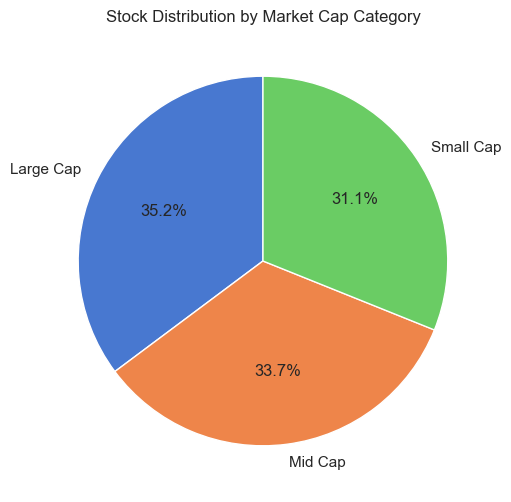

In [6]:
cap_counts = dataset['Cap Category'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(cap_counts, labels=cap_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Stock Distribution by Market Cap Category")
plt.show()



35.2% of Stocks falls under Large Cap, 33.7% under Mid Cap and rest of them falls under Small Cap category.

## 4. Which stocks had the highest and lowest Correlation with Nifty?

In [7]:
high = dataset['Corr_with_NIFTY'].max()
low = dataset['Corr_with_NIFTY'].min()
highest_stk = dataset[dataset['Corr_with_NIFTY']==high]['Stock'].item()
lowest_stk = dataset[dataset['Corr_with_NIFTY']==low]['Stock'].item()

print(f'{highest_stk} Stock had the Highest Correlation with Nifty of {high*100:1.2f}%')
print(f'{lowest_stk} Stock had the Lowest Lowest Correlation with of {low*100:1.2f}%')


RELIANCE Stock had the Highest Correlation with Nifty of 71.03%
CGCL Stock had the Lowest Lowest Correlation with of 8.52%


## 5. What is the distribution of Market Cap across all Cap Categories? 

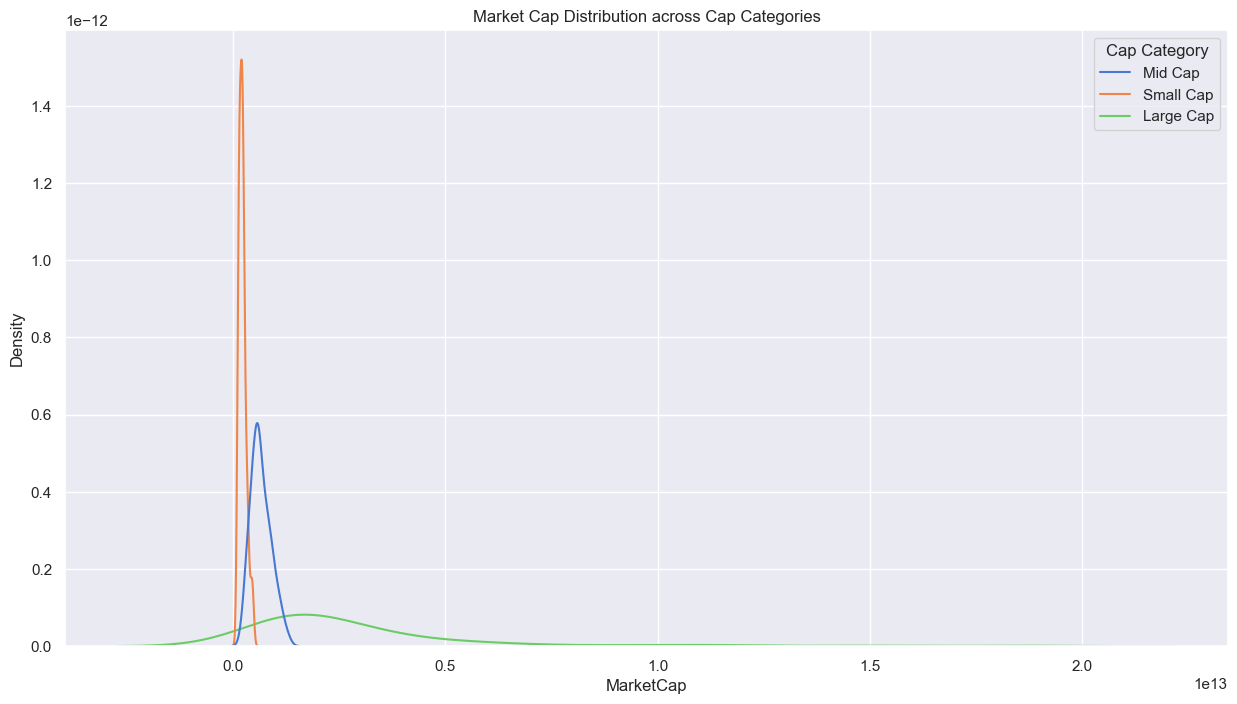

In [8]:
plt.figure(figsize=(15, 8))
ax = sns.kdeplot(dataset, x='MarketCap', hue='Cap Category')
plt.title('Market Cap Distribution across Cap Categories')
plt.show()


Large cap companies have much higher market capitalizations than mid and small cap companies; most small and mid cap stocks are tightly grouped at low values, while large caps show a much wider and higher spread.

## 6. Distribution of Annualised Voatility based on Sectors

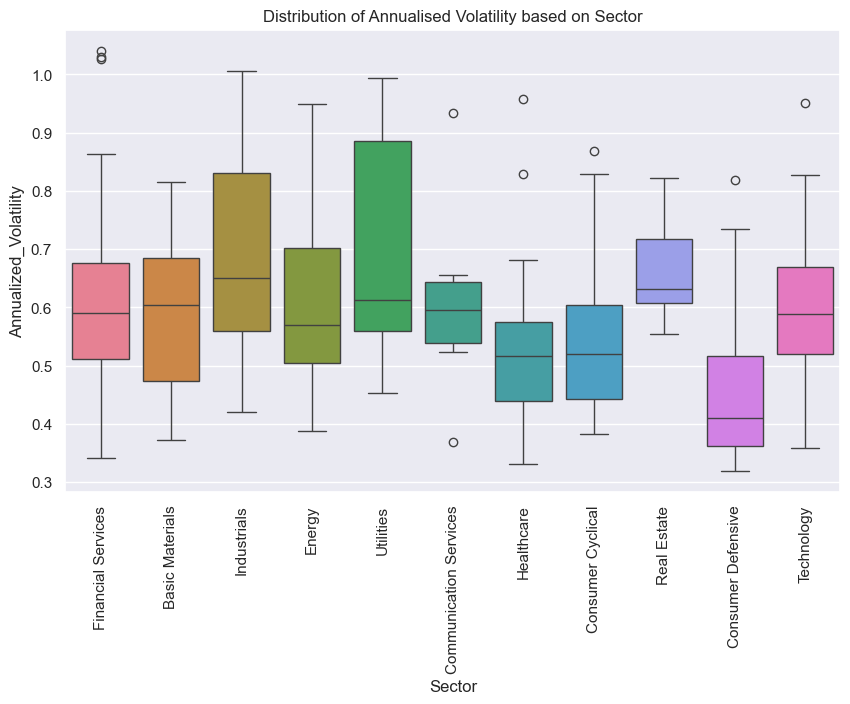

In [9]:

plt.figure(figsize=[10,6])
sns.boxplot(dataset,x='Sector', y='Annualized_Volatility',  hue='Sector')
plt.xticks(rotation=90)
plt.title('Distribution of Annualised Volatility based on Sector')
plt.show()




Utilities and Industrials sectors experience bigger fluctuations, while Consumer Defensive and Healthcare sectors tend to have lower and more stable volatility.Most stocks have low to moderate volatility, with standard deviations of daily and monthly returns clustered at lower values and just a few stocks exhibiting very high volatility.

## 7. Which market capitalization category offers the highest average risk-adjusted returns based on the Sharpe ratio?

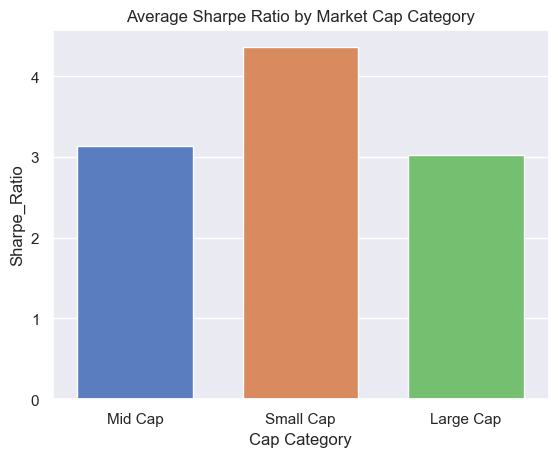

In [10]:
sns.barplot(dataset, x='Cap Category', y='Sharpe_Ratio', errorbar=None, width=0.7, hue='Cap Category', legend=False)
plt.title('Average Sharpe Ratio by Market Cap Category')
plt.show()


Small cap stocks have the highest average Sharpe ratio, indicating better risk-adjusted returns compared to mid cap and large cap stocks.

## 8. How severe are stock crashes measured by Max Drawdown

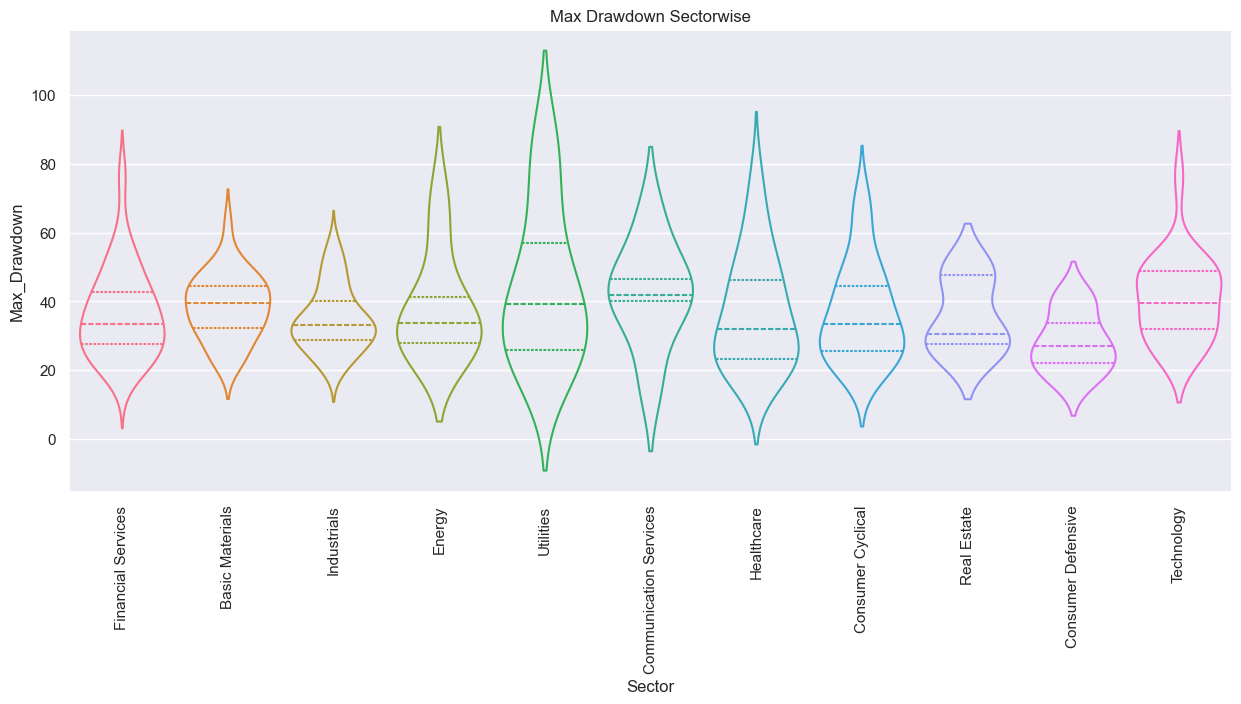

In [11]:
plt.figure( figsize=(15, 6))

# sns.swarmplot(dataset, y='Max_Drawdown', color='lightgreen', ax=axes[0])
sns.violinplot(dataset, y='Max_Drawdown', x='Sector', fill=False, inner='quartile', hue='Sector')
plt.title('Max Drawdown Sectorwise')
plt.xticks(rotation=90)
plt.show()


Utilities and Healthcare sectors have the widest range of maximum drawdowns, meaning some stocks in these sectors experienced very large drops, while Consumer Defensive stocks generally show smaller and more stable losses.

In [12]:
largecap_crash = dataset[dataset['Cap Category'] == 'Large Cap'][['Sector', 'Max_Drawdown']].sort_values(by='Max_Drawdown', ascending=False).head(3)
midcap_crash = dataset[dataset['Cap Category'] == 'Mid Cap'][['Sector', 'Max_Drawdown']].sort_values(by='Max_Drawdown', ascending=False).head(3)
smallcap_crash = dataset[dataset['Cap Category'] == 'Small Cap'][['Sector', 'Max_Drawdown']].sort_values(by='Max_Drawdown', ascending=False).head(3)

print(f'For Large Cap Stocks, highest crash is around {largecap_crash.values[1][1]:.2f}%, {largecap_crash.values[2][1]:.2f}%  in Sectors like {largecap_crash.values[1][0]} and {largecap_crash.values[2][0]}')
print(f'For Mid Cap Stocks, highest crash is around {midcap_crash.values[0][1]:.2f}%, {midcap_crash.values[1][1]:.2f}% in Sectors like {midcap_crash.values[0][0]} and {midcap_crash.values[1][0]}')
print(f'For Small Cap Stocks, highest crash is around {smallcap_crash.values[0][1]:.2f}%, {smallcap_crash.values[1][1]:.2f}% in Sectors like {smallcap_crash.values[0][0]} and {smallcap_crash.values[1][0]}')


For Large Cap Stocks, highest crash is around 71.35%, 70.53%  in Sectors like Energy and Consumer Cyclical
For Mid Cap Stocks, highest crash is around 86.46%, 76.33% in Sectors like Utilities and Technology
For Small Cap Stocks, highest crash is around 77.91%, 77.55% in Sectors like Financial Services and Healthcare


## 9. How frequent are Volume Spikes across stocks?

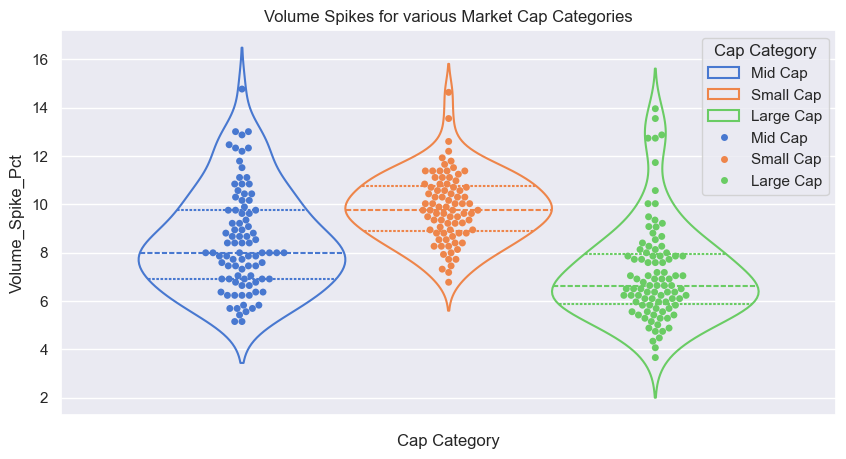

In [13]:
plt.figure(figsize=[10,5])
sns.violinplot(dataset, y='Volume_Spike_Pct', hue='Cap Category', fill=False, inner='quart')
sns.swarmplot(dataset, y='Volume_Spike_Pct', hue='Cap Category', dodge=True)
plt.xlabel('Cap Category')
plt.title('Volume Spikes for various Market Cap Categories')
plt.show()


Small cap and mid cap stocks show more frequent volume spikes compared to large cap stocks.

## 10. Do Stocks with higher Volume Spike % have higher Avg Volume

Average Volume tends to increase as Volume Spike Percent increases (correlation: 0.16)


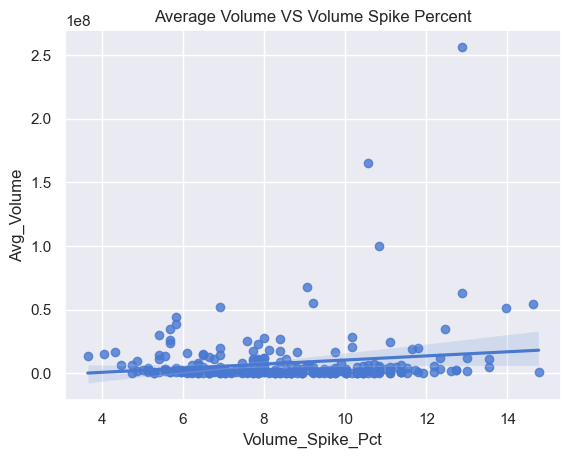

In [14]:
volspike_avgvol = dataset[['Volume_Spike_Pct','Avg_Volume']].corr()
result=volspike_avgvol['Volume_Spike_Pct']['Avg_Volume'].item()

print(f'Average Volume tends to increase as Volume Spike Percent increases (correlation: {result:.2f})' if result > 0 else f'Average Volume tends to decrease as Volume Spike Percent increases (correlation: {result:.2f})')


sns.regplot(dataset, x='Volume_Spike_Pct', y='Avg_Volume')
plt.title('Average Volume VS Volume Spike Percent')
plt.show()


## 11. What Sectors fall under each Cap Categories?

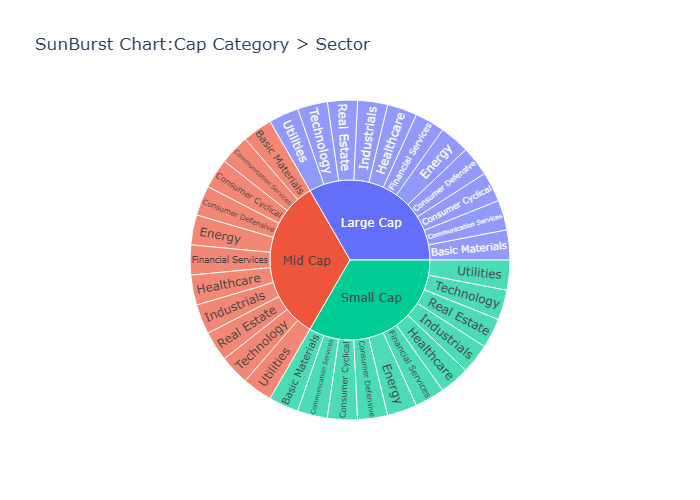

In [17]:
stk_category=(dataset.groupby(['Cap Category','Sector']).count().reset_index()) [['Cap Category', 'Sector']]

fig_sunburst = px.sunburst(
    stk_category,
    path=['Cap Category', 'Sector'],
    title='SunBurst Chart:Cap Category > Sector',
    width=1100,
    height=600
)

# fig_sunburst.show()
fig_sunburst.write_image("plotly_chart.png")
from IPython.display import Image
Image("plotly_chart.png")


All cap size categories—large cap, mid cap, and small cap—contain stocks from a diverse range of sectors, indicating that every industry includes companies of various sizes.

## 12. How do quantitative features relate to each other?

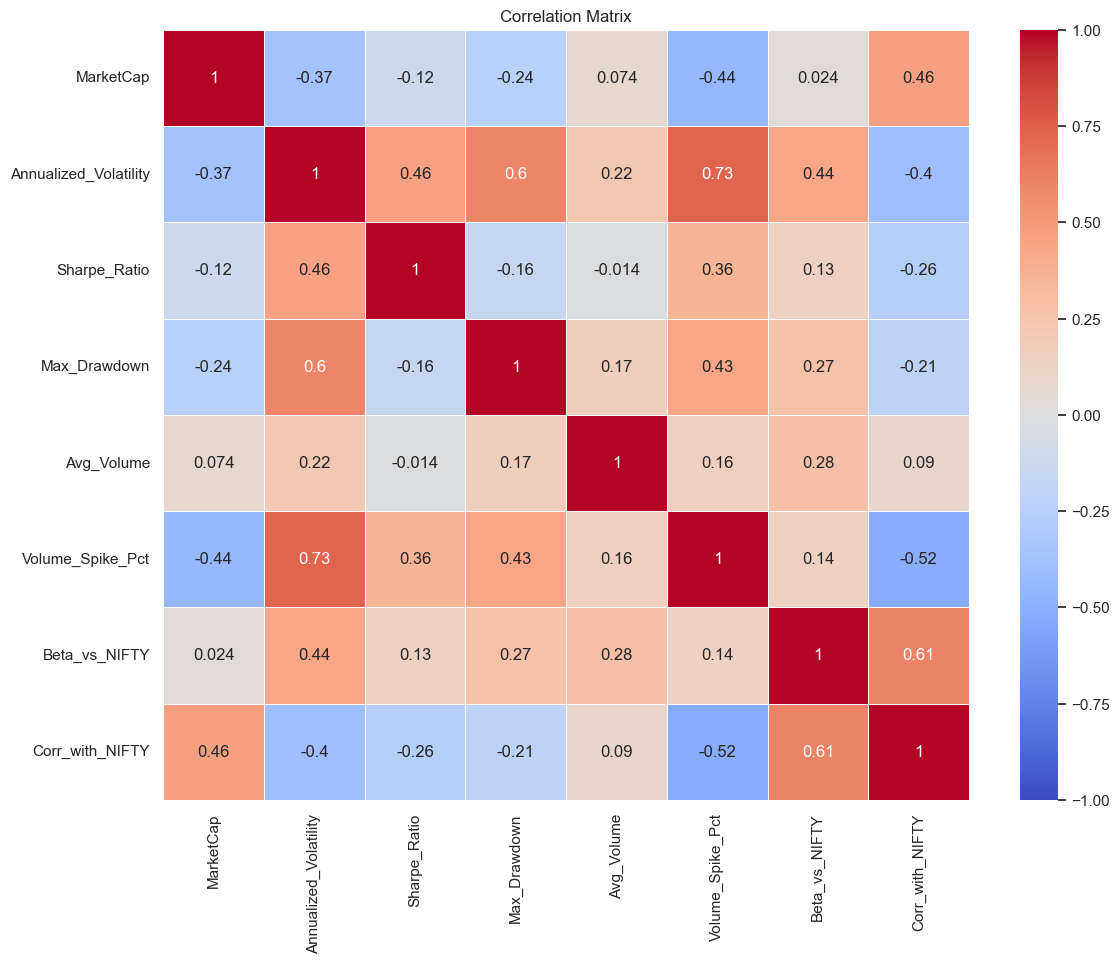

In [99]:
data_corr=dataset[quan].corr()
plt.figure(figsize=[13,10])
sns.heatmap(data_corr, vmax=1, vmin=-1, center=0, annot=True, linewidths=0.5, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


Annualized volatility is strongly associated with both volume spikes and max drawdown, while market cap is moderately correlated with how closely a stock moves with the Nifty index.